# Model 1A: Decision-Tree Baseline

This notebook builds a decision-tree baseline for flights departing John F. Kennedy International Airport (JFK). The target, `DepDel15`, equals 1 when departure delay is at least 15 minutes and 0 otherwise.

To support a fair comparison with the logistic-regression baseline, this notebook uses the same raw pre-departure predictors, missing-row rule, stratified 2019 train/test split, random seed, evaluation metrics, and 0.5 classification threshold. It does not use engineered features, class weighting, resampling, or test-set hyperparameter tuning.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
TEST_SIZE = 0.20

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## Load the 2019 model-assembly data

The path lookup allows the notebook to run from either the capstone directory or the `models` subdirectory.

In [2]:
def find_project_root(start: Path) -> Path:
    """Return the nearest parent containing the expected 2019 model file."""
    for candidate in (start, *start.parents):
        if (candidate / "data/models/JFK_2019_m1a.csv").exists():
            return candidate
    raise FileNotFoundError("Could not locate data/models/JFK_2019_m1a.csv")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data/models/JFK_2019_m1a.csv"

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Data source: {DATA_PATH}")
print(f"Rows: {len(df):,}; columns: {df.shape[1]:,}")

Data source: /Users/johnkyte/Projects/berkeley_ml_and_ai/capstone/data/models/JFK_2019_m1a.csv
Rows: 124,759; columns: 71


In [3]:
TARGET = "DepDel15"

target_summary = (
    df[TARGET]
    .value_counts(dropna=False)
    .rename_axis(TARGET)
    .to_frame("flights")
)
target_summary["share"] = target_summary["flights"] / len(df)
target_summary

,flights,share
DepDel15,,
0.0000,101213,0.8113
1.0000,23546,0.1887


## Select raw predictors available before departure

The feature set matches the logistic-regression baseline and covers calendar and schedule information, airline and destination, planned ASPM traffic, and raw NOAA weather measurements.

Categorical fields are one-hot encoded. Numeric fields pass through unchanged because tree splits depend on value ordering rather than feature scale; standardization would not change their possible split points. Encoding is preprocessing and does not add engineered predictors.

Actual departure, taxi, takeoff, and arrival fields are excluded because they would leak the outcome. Identifiers, join-audit timestamps, constants, redundant representations, and existing derived fields such as `WindX`, `WindY`, and `PrecipOccurred` are also excluded.

In [4]:
# Month and weekday are categories rather than continuous measurements.
categorical_features = [
    "Month",
    "DayOfWeek",
    "Reporting_Airline",
    "Dest",
]

# These raw measurements can be split directly by the decision tree.
numeric_features = [
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "ASPM_PREVIOUS_SCHEDULED_DEPARTURES",
    "ASPM_PREVIOUS_SCHEDULED_ARRIVALS",
    "ASPM_CURRENT_SCHEDULED_DEPARTURES",
    "ASPM_CURRENT_SCHEDULED_ARRIVALS",
    "ASPM_NEXT_SCHEDULED_DEPARTURES",
    "ASPM_NEXT_SCHEDULED_ARRIVALS",
    "HourlyDewPointTemperature",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyRelativeHumidity",
    "HourlyVisibility",
    "HourlyWindSpeed",
]

feature_columns = categorical_features + numeric_features
required_columns = [TARGET, *feature_columns]
missing_columns = sorted(set(required_columns) - set(df.columns))
assert not missing_columns, f"Required columns are missing: {missing_columns}"

print(f"Selected {len(feature_columns)} raw predictors:")
print(f"  categorical: {len(categorical_features)}")
print(f"  numeric: {len(numeric_features)}")

Selected 20 raw predictors:
  categorical: 4
  numeric: 16


## Handle missing values

A few flights at the end of December have missing next-hour ASPM values because their next clock-hour lookup falls in the 2020 ASPM file, while this model-assembly file contains 2019 data. Those rows are dropped for this baseline because the affected count is negligible and unknown planned traffic must not be interpreted as zero.

A later data-preparation revision could join the first required ASPM hour from the following year instead.

In [5]:
model_df = df[required_columns].copy()

# Make the reason and size of the row exclusion visible before dropping data.
missing_summary = model_df.isna().sum()
display(missing_summary[missing_summary.gt(0)].to_frame("missing_rows"))

rows_before_drop = len(model_df)
model_df = model_df.dropna(subset=required_columns).copy()
model_df[TARGET] = model_df[TARGET].astype(int)
rows_dropped = rows_before_drop - len(model_df)

print(f"Dropped rows: {rows_dropped:,}")
print(f"Rows retained: {len(model_df):,} ({len(model_df) / rows_before_drop:.3%})")
assert not model_df[required_columns].isna().any().any()

,missing_rows
ASPM_NEXT_SCHEDULED_DEPARTURES,3
ASPM_NEXT_SCHEDULED_ARRIVALS,3


Dropped rows: 3
Rows retained: 124,756 (99.998%)


## Reproduce the stratified 2019 train/test split

A reproducible 80/20 random split is stratified on `DepDel15`, preserving approximately the same delayed-flight rate in both partitions. The seed and split size match the logistic-regression notebook so both models receive the same training and test rows.

Only 2019 is used; the 2023 and 2024 datasets remain completely unused.

In [6]:
X = model_df[feature_columns]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "delayed_flights": [y_train.sum(), y_test.sum()],
        "delay_rate": [y_train.mean(), y_test.mean()],
    },
    index=["train", "test"],
)
split_summary

,rows,delayed_flights,delay_rate
train,99804,18837,0.1887
test,24952,4709,0.1887


## Build the decision-tree pipeline

The tree hyperparameters are fixed before examining test results:

- `criterion="gini"`: the standard, efficient classification impurity measure.
- `max_depth=10`: allows nonlinear interactions while limiting a fully grown tree's tendency to memorize training rows.
- `min_samples_split=500`: prevents a node from splitting unless it represents a meaningful number of flights.
- `min_samples_leaf=200`: requires each terminal segment to contain at least 200 training flights, producing more stable probability estimates.
- `class_weight=None`: preserves the same unweighted baseline objective as logistic regression; imbalance treatments can be compared later.
- `random_state=42`: makes any tie-breaking behavior reproducible.

These are conservative baseline choices, not test-optimized values. Later tuning should use cross-validation on the training partition only.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        ("numeric", "passthrough", numeric_features),
    ],
    remainder="drop",
)

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                criterion="gini",
                max_depth=10,
                min_samples_split=500,
                min_samples_leaf=200,
                class_weight=None,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

dummy_model = DummyClassifier(strategy="prior")

In [8]:
# Fit the encoder and tree using training rows only.
decision_tree_pipeline.fit(X_train, y_train)
dummy_model.fit(X_train, y_train)

fitted_tree = decision_tree_pipeline.named_steps["classifier"]
print("Decision-tree and dummy baselines fitted.")
print(f"Tree depth: {fitted_tree.get_depth()}")
print(f"Terminal leaves: {fitted_tree.get_n_leaves():,}")

Decision-tree and dummy baselines fitted.
Tree depth: 10
Terminal leaves: 172


## Evaluate the held-out test set

Accuracy is reported but is not sufficient because delayed flights are the minority class. Balanced accuracy, precision, recall, F1, ROC AUC, and average precision provide complementary views of performance. The dummy classifier establishes the majority-class reference.

In [9]:
def evaluate_classifier(model, X_values, y_values, model_name, partition):
    """Return threshold and ranking metrics for one fitted classifier."""
    predictions = model.predict(X_values)
    probabilities = model.predict_proba(X_values)[:, 1]
    return {
        "partition": partition,
        "model": model_name,
        "accuracy": accuracy_score(y_values, predictions),
        "balanced_accuracy": balanced_accuracy_score(y_values, predictions),
        "precision": precision_score(y_values, predictions, zero_division=0),
        "recall": recall_score(y_values, predictions, zero_division=0),
        "f1": f1_score(y_values, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_values, probabilities),
        "average_precision": average_precision_score(y_values, probabilities),
    }


evaluation_results = pd.DataFrame(
    [
        evaluate_classifier(dummy_model, X_test, y_test, "Dummy (class prior)", "test"),
        evaluate_classifier(decision_tree_pipeline, X_train, y_train, "Decision tree", "train"),
        evaluate_classifier(decision_tree_pipeline, X_test, y_test, "Decision tree", "test"),
    ]
).set_index(["partition", "model"])

evaluation_results

,,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
partition,model,,,,,,,
test,Dummy (class prior),0.8113,0.5000,0.0000,0.0000,0.0000,0.5000,0.1887
train,Decision tree,0.8204,0.5601,0.6032,0.1420,0.2298,0.7181,0.3957
test,Decision tree,0.8181,0.5588,0.5726,0.1423,0.2279,0.6991,0.3788


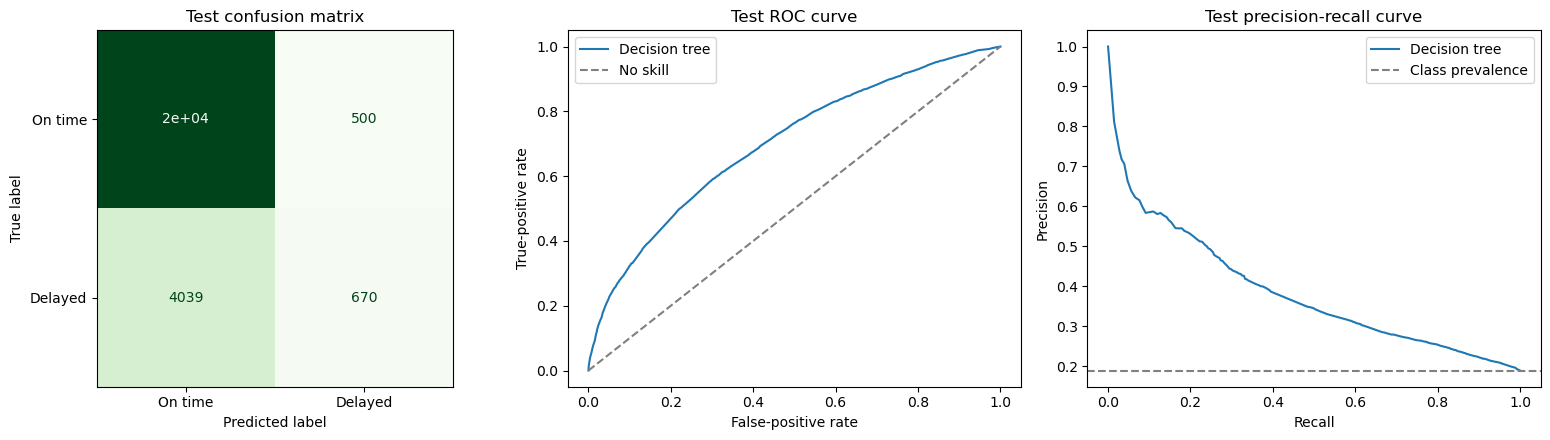

In [10]:
test_predictions = decision_tree_pipeline.predict(X_test)
test_probabilities = decision_tree_pipeline.predict_proba(X_test)[:, 1]

false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probabilities)
curve_precision, curve_recall, _ = precision_recall_curve(y_test, test_probabilities)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["On time", "Delayed"],
    cmap="Greens",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Test confusion matrix")

axes[1].plot(false_positive_rate, true_positive_rate, label="Decision tree")
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray", label="No skill")
axes[1].set(xlabel="False-positive rate", ylabel="True-positive rate", title="Test ROC curve")
axes[1].legend()

axes[2].plot(curve_recall, curve_precision, label="Decision tree")
axes[2].axhline(y_test.mean(), linestyle="--", color="gray", label="Class prevalence")
axes[2].set(xlabel="Recall", ylabel="Precision", title="Test precision-recall curve")
axes[2].legend()

fig.tight_layout()
plt.show()

## Inspect feature importance

Impurity-based importance shows which encoded inputs most reduced Gini impurity in this fitted tree. It can favor continuous or high-cardinality predictors, so it should be treated as a diagnostic rather than a causal or definitive feature ranking.

In [11]:
feature_names = decision_tree_pipeline.named_steps["preprocessor"].get_feature_names_out()
feature_importance = (
    pd.Series(
        fitted_tree.feature_importances_,
        index=feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
    .head(20)
    .to_frame()
)
feature_importance

,importance
numeric__CRSDepTime,0.3220
numeric__HourlyRelativeHumidity,0.1682
numeric__HourlyDewPointTemperature,0.1283
numeric__HourlyDryBulbTemperature,0.0753
numeric__HourlyWindSpeed,0.0686
categorical__Month_10,0.0287
numeric__CRSElapsedTime,0.0207
categorical__Month_9,0.0167
numeric__ASPM_PREVIOUS_SCHEDULED_DEPARTURES,0.0162
categorical__Month_7,0.0162


## Visualize the top of the tree

The fitted tree can contain ten levels, so the diagram intentionally shows only the first three levels. This provides an interpretable view of the earliest splits without producing an unreadable full-tree graphic.

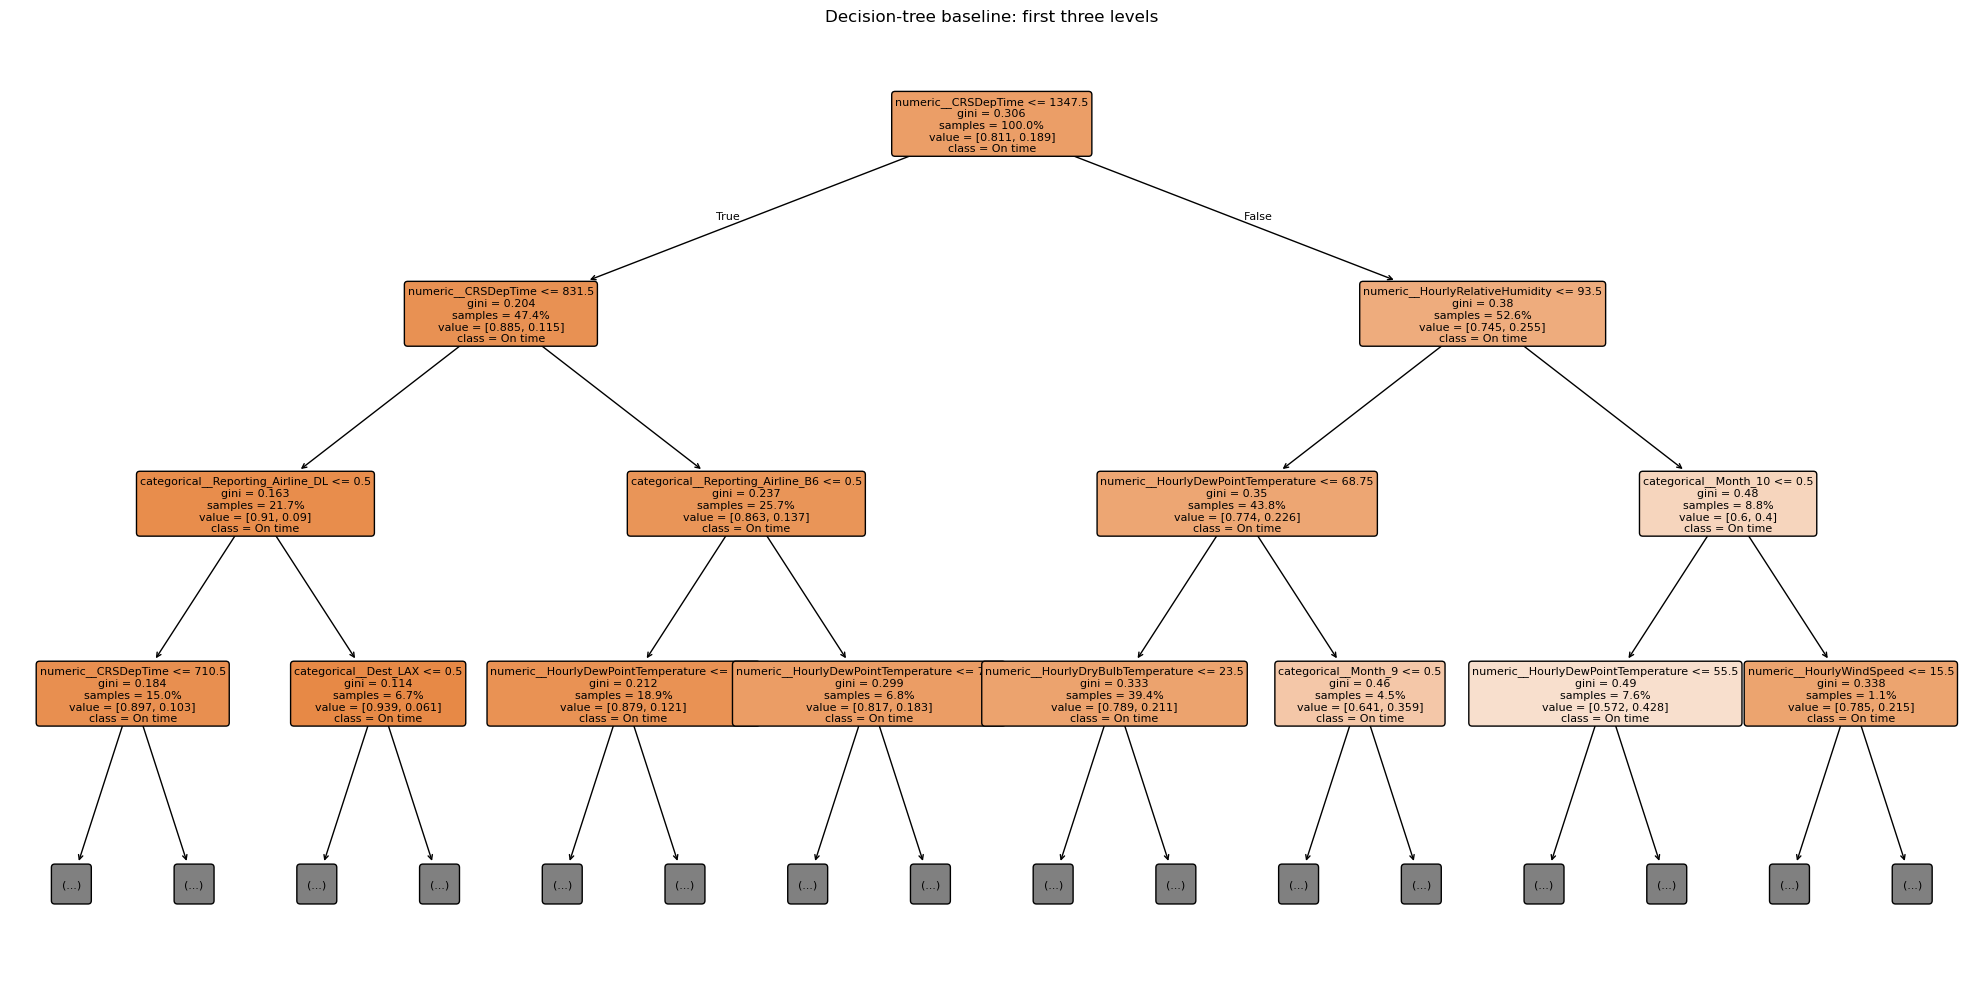

In [12]:
fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    fitted_tree,
    feature_names=feature_names,
    class_names=["On time", "Delayed"],
    max_depth=3,
    filled=True,
    rounded=True,
    proportion=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Decision-tree baseline: first three levels")
plt.tight_layout()
plt.show()

## Baseline interpretation

The held-out test metrics are the primary result. Compare the decision tree with both the dummy classifier and the logistic-regression baseline, paying particular attention to ROC AUC, average precision, delayed-flight recall, and the train-test gap.

A substantial train-test gap would indicate that the tree remains too flexible; similar train and test performance with weak ranking metrics would indicate underfitting. Later work can tune depth, leaf size, class weighting, and pruning using cross-validation on the training partition only. Because this pass uses a random 2019 split, a later phase should also test temporal robustness on later periods.